## Test CMIP6 search with CMIP6py

In [ ]:
import os
import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)

from cmip6py.search.cmip6_search import CMIP6Search

In [19]:
search_facets = {"experiment_id": ["historical", "ssp245"], 
                 "source_id": ["EC-Earth3", "MPI-ESM1-2-HR"], 
                 "variable": ["ua", "va"],
                 "table_id": ["Eday", "day", "Oday"]}
search_filters = {
    "experiment_id": ["historical", "ssp245"],
    "years": {"historical": [2010, 2015], "projections": [2015, 2021]},
}
strict_variable_set = search_facets["variable"]

In [21]:
cmip6_search = CMIP6Search(
    random_seed=42, 
    max_workers=os.cpu_count(),
)
cmip6_search.search(search_facets)
cmip6_search

INFO:cmip6py.search.search_utils:Submitted 8 parallel searches (max_workers=12)
INFO:cmip6py.search.cmip6_search:Got 371250 from ESGF nodes with facets={'experiment_id': ['historical', 'ssp245'], 'source_id': ['EC-Earth3', 'MPI-ESM1-2-HR'], 'variable': ['ua', 'va'], 'table_id': ['Eday', 'day', 'Oday']}


CMIP6Search:random_seed=42,n_datasets=368,nodes_are_filtered=False,members_are_balanced=False

In [22]:
cmip6_search.datasets[0]

CMIP6Dataset:EC-Earth3_historical_r101i1p1f1_ua_19700101-20141231

/Users/eliotwalt/Documents/phd/code/CMIP6py/cmip6py/search/cmip6_search.py:305: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend().remove()


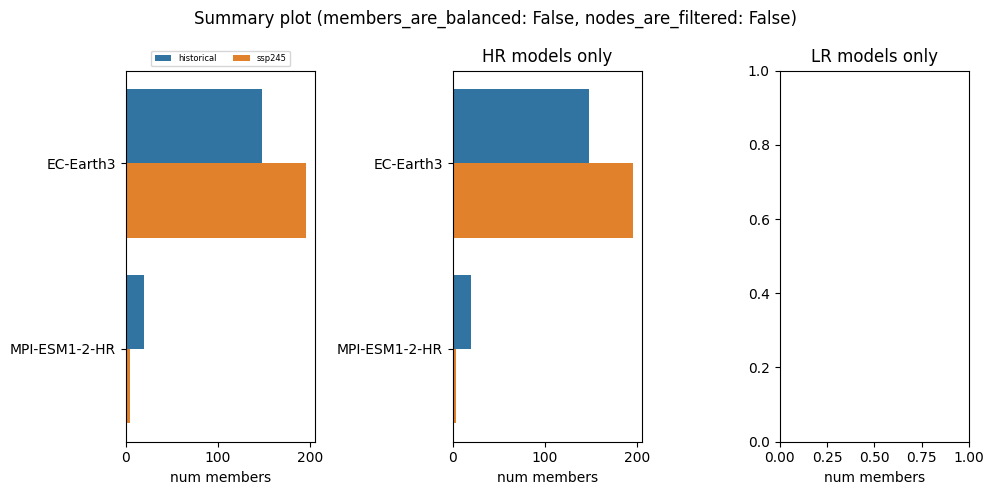

In [23]:
cmip6_search.summary_plot()

In [25]:
filtered_cmip6_search = (cmip6_search.filter("facets", experiment_id=["historical", "ssp245"]) # only historical and SSP-2.45
                                         .filter("years", historical=[2010, 2015], projections=[2015, 2021])) # select years
filtered_cmip6_search

CMIP6Search:random_seed=42,n_datasets=368,nodes_are_filtered=False,members_are_balanced=False

In [27]:
avail_cmip6_search = filtered_cmip6_search.filter("running_nodes")
avail_cmip6_search

CMIP6Search:random_seed=42,n_datasets=0,nodes_are_filtered=True,members_are_balanced=False

/Users/eliotwalt/Documents/phd/code/CMIP6py/cmip6py/search/cmip6_search.py:307: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend(ncols=3, bbox_to_anchor=(0.5, 1.0), loc="lower center", fontsize=6)
/Users/eliotwalt/Documents/phd/code/CMIP6py/cmip6py/search/cmip6_search.py:305: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend().remove()
/Users/eliotwalt/Documents/phd/code/CMIP6py/cmip6py/search/cmip6_search.py:305: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend().remove()


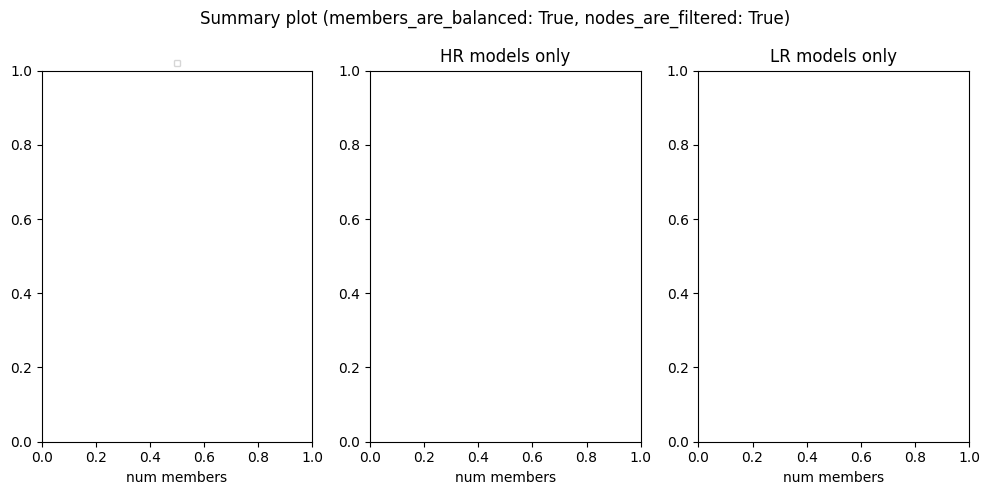

In [28]:
avail_balanced_cmip6_search = avail_cmip6_search.balance_members(num_members=4, tolerance=2)
avail_balanced_cmip6_search.summary_plot()

In [30]:
avail_balanced_cmip6_search.download("cmip6_data/")

In [31]:
avail_balanced_cmip6_search.dataset_to_local_files

AttributeError: 'CMIP6Search' object has no attribute 'dataset_to_local_files'